<a href="https://colab.research.google.com/github/fdac25/MP2/blob/main/Vis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Mini Project Part 2
import pandas as pd
import matplotlib.pyplot as plt

# Creating pmarino_commits_timeseries_.csv
# Groups activity by month

yournetid = "pmarino"

# Read Part 1 CSV
df = pd.read_csv(
    yournetid + "_project_summary.csv",
    sep=";"
)

# Convert Unix timestamp to datetime
df["datetime"] = pd.to_datetime(
    df["time"],
    unit="s",
    utc=True
)

# Convert each commit to its month
df["Month"] = (
    df["datetime"]
    .dt.tz_convert(None)
    .dt.to_period("M")
)

# Count commits in each month
monthly_counts = df.groupby("Month").size()

# Create every month from the first commit month to the last commit month
all_months = pd.period_range(
    start=df["Month"].min(),
    end=df["Month"].max(),
    freq="M"
)

# Insert 0 for months that had no commits
monthly_counts = monthly_counts.reindex(
    all_months,
    fill_value=0
)

# Create required dataframe
timeseries_df = pd.DataFrame({
    "Month": monthly_counts.index.astype(str),
    "#Commits": monthly_counts.values
})

# Save as semicolon-separated CSV
timeseries_df.to_csv(
    yournetid + "_commits_timeseries_.csv",
    sep=";",
    index=False
)

timeseries_df.head(10)



,Month,#Commits
0,2003-05,63
1,2003-06,17
2,2003-07,41
3,2003-08,12
4,2003-09,16
5,2003-10,27
6,2003-11,13
7,2003-12,9
8,2004-01,3
9,2004-02,6


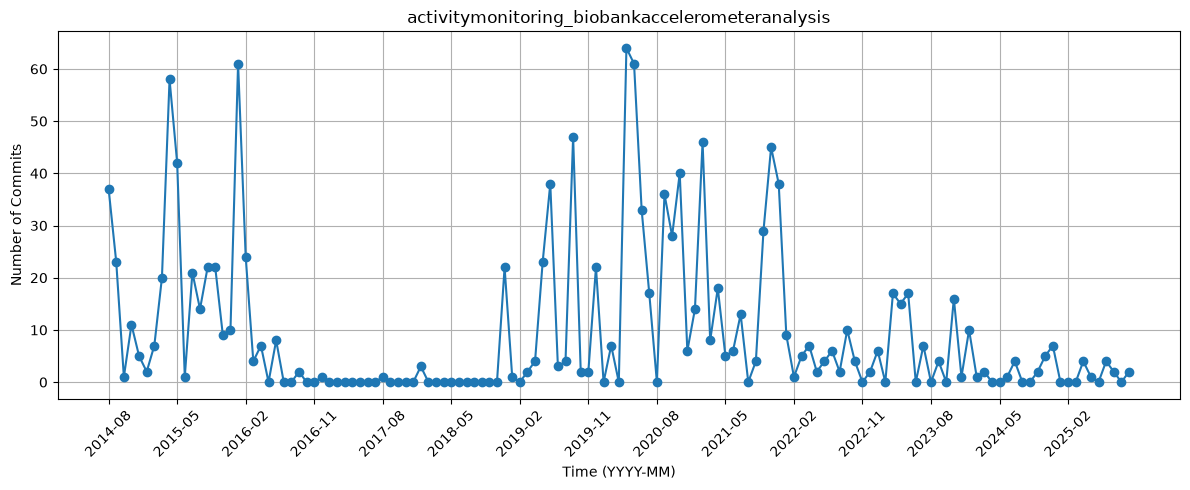

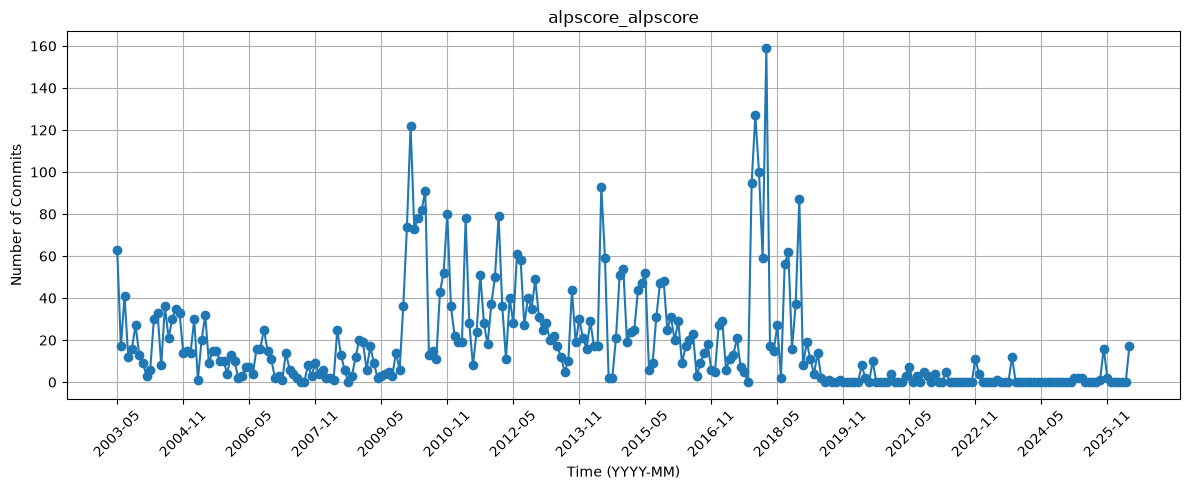

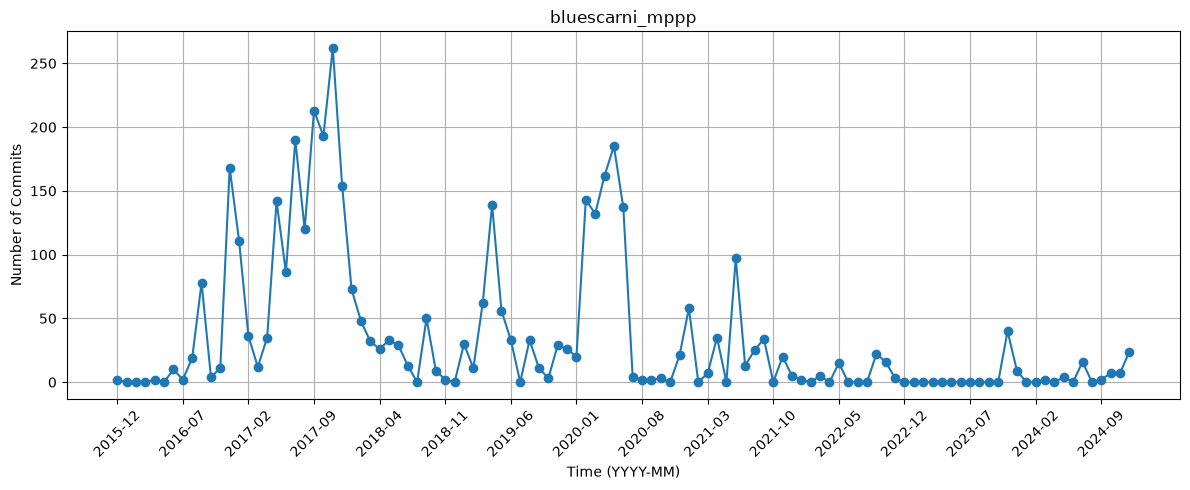

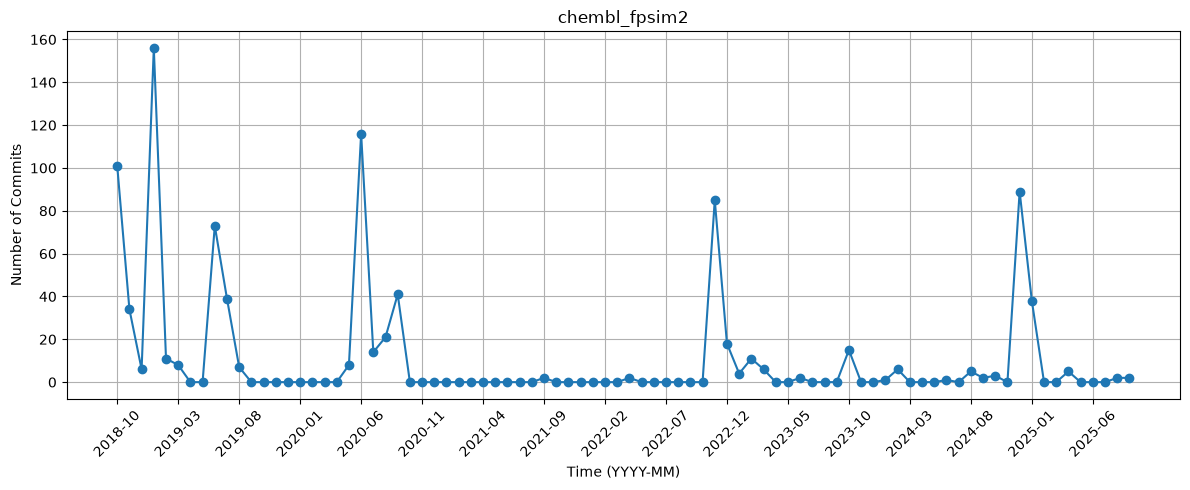

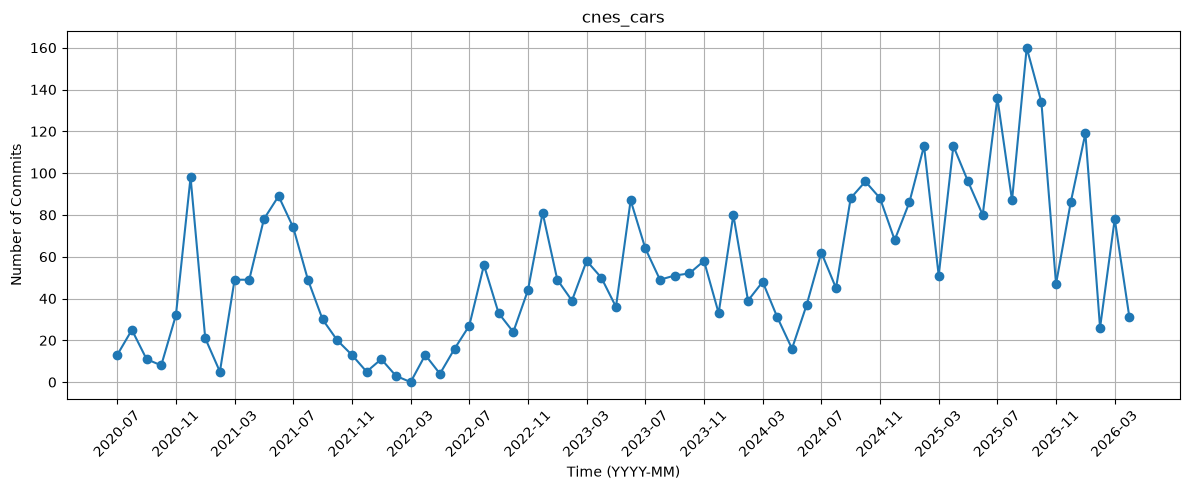

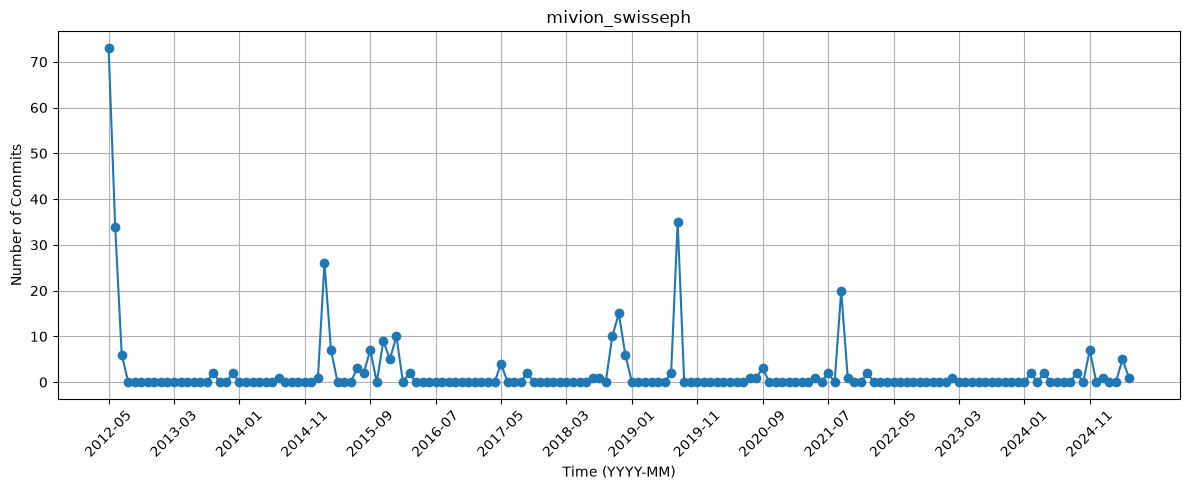

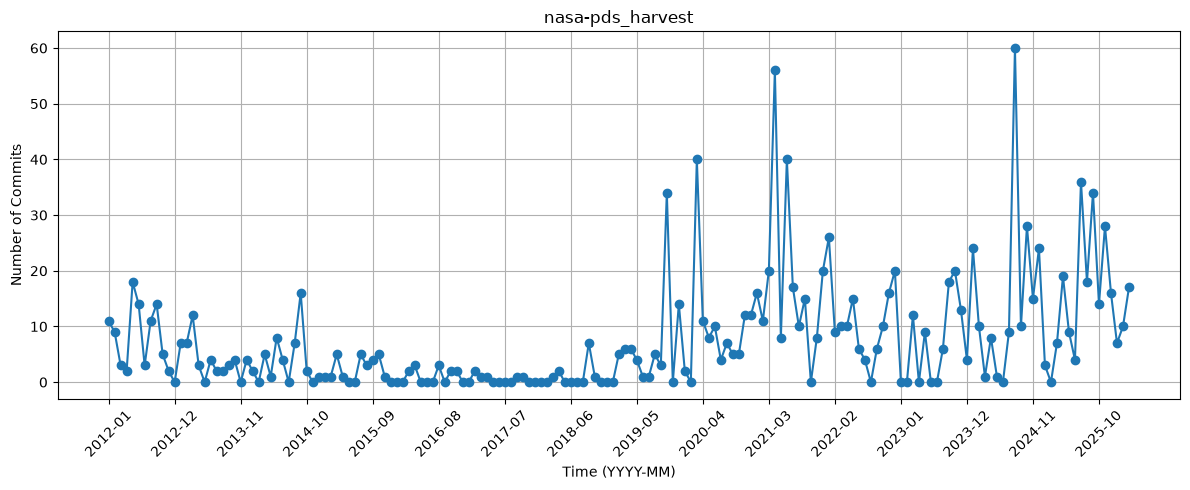

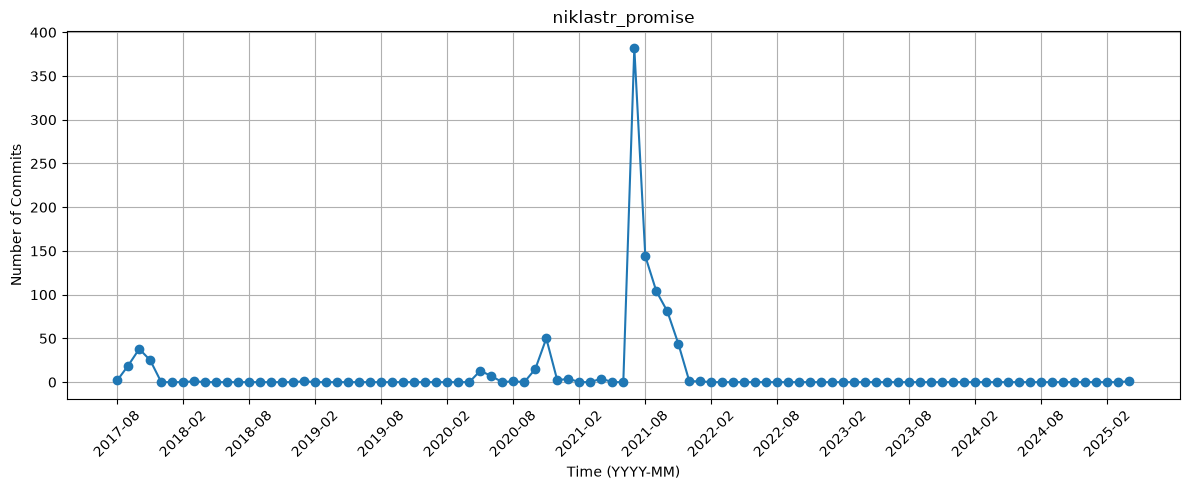

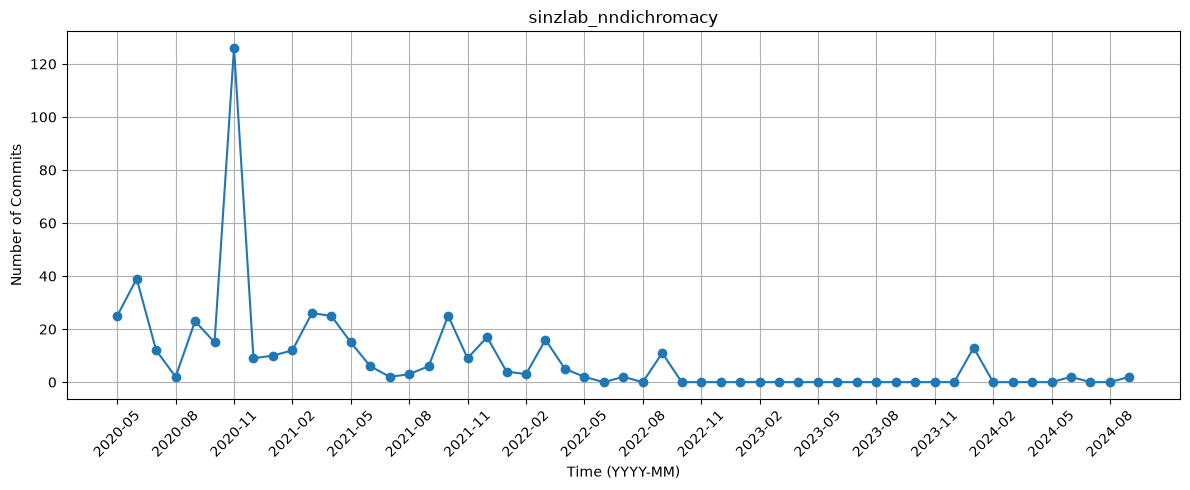

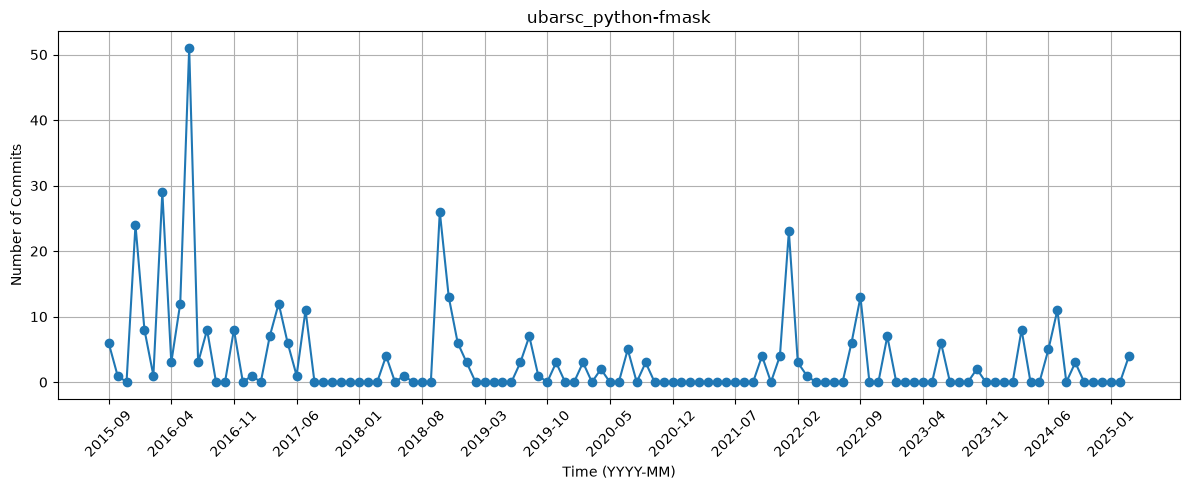

In [2]:
# Creates a line plot of the time series in Python
import pandas as pd
import matplotlib.pyplot as plt

yournetid = "pmarino"

# Load Part 1 data
df = pd.read_csv(
    yournetid + "_project_summary.csv",
    sep=";"
)

# Convert Unix timestamp to datetime
df["datetime"] = pd.to_datetime(
    df["time"],
    unit="s",
    utc=True
).dt.tz_convert(None)

# Create one plot for each WoC project
for project_id, project_df in df.groupby("project_wocid"):

    # Convert commit times to months
    months = project_df["datetime"].dt.to_period("M")

    # Count commits per month
    monthly_counts = months.value_counts().sort_index()

    # Include months with zero commits
    all_months = pd.period_range(
        start=months.min(),
        end=months.max(),
        freq="M"
    )

    monthly_counts = monthly_counts.reindex(
        all_months,
        fill_value=0
    )

    # Build plotting dataframe
    plot_df = pd.DataFrame({
        "Month": monthly_counts.index.astype(str),
        "#Commits": monthly_counts.values
    })

    # Plot
    plt.figure(figsize=(12, 5))
    plt.plot(
        plot_df["Month"],
        plot_df["#Commits"],
        marker="o",
        linestyle="-"
    )

    plt.xlabel("Time (YYYY-MM)")
    plt.ylabel("Number of Commits")
    plt.title(project_id)
    plt.grid(True)

    # Don't print every month label if there are many years of data
    step = max(1, len(plot_df) // 15)
    plt.xticks(
        range(0, len(plot_df), step),
        plot_df["Month"].iloc[::step],
        rotation=45
    )

    plt.tight_layout()

    # Save at required resolution
    filename = f"{yournetid}_timeseries_{project_id}.png"
    plt.savefig(filename, dpi=300)

    plt.show()
    plt.close()